Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using ZIPs:
  Good: /content/drive/MyDrive/RoadDamageBD/Good_Roads.zip
  Bad : /content/drive/MyDrive/RoadDamageBD/Damaged_Roads.zip
Extracting: /content/drive/MyDrive/RoadDamageBD/Good_Roads.zip
Extracted 125 images → 'Good_Roads'
Extracting: /content/drive/MyDrive/RoadDamageBD/Damaged_Roads.zip
Extracted 325 images → 'Damaged_Roads'
Train/Val split complete.
Using device: cpu
Classes: ['Damaged_Roads', 'Good_Roads']
Model Loaded.

Epoch 1/5


Training:   0%|          | 0/12 [00:00<?, ?it/s]

Validating:   0%|          | 0/3 [00:00<?, ?it/s]

Train Acc=0.847 | Val Acc=0.511

Epoch 2/5


Training:   0%|          | 0/12 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/3 [00:00<?, ?it/s]

Train Acc=0.897 | Val Acc=0.500

Epoch 5/5


Training:   0%|          | 0/12 [00:00<?, ?it/s]

Validating:   0%|          | 0/3 [00:00<?, ?it/s]

Train Acc=0.897 | Val Acc=0.767


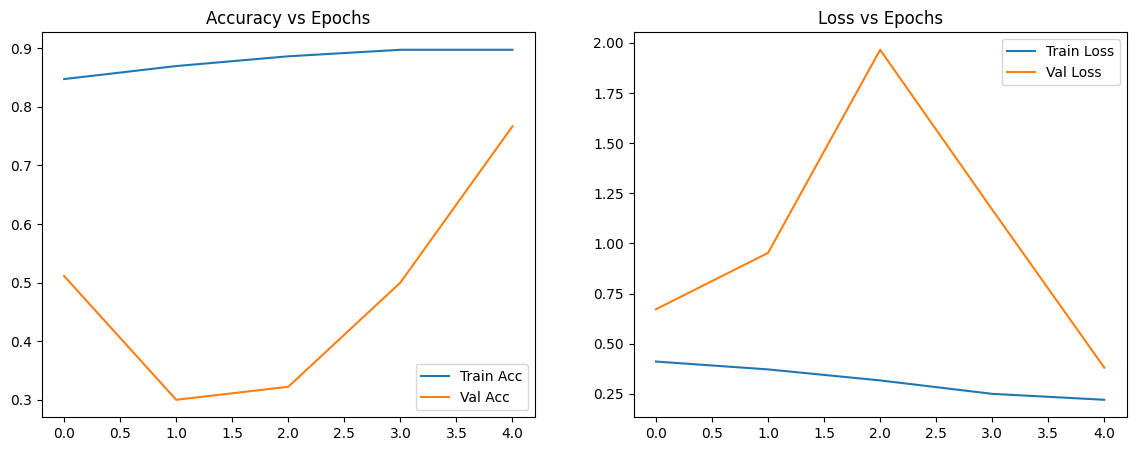

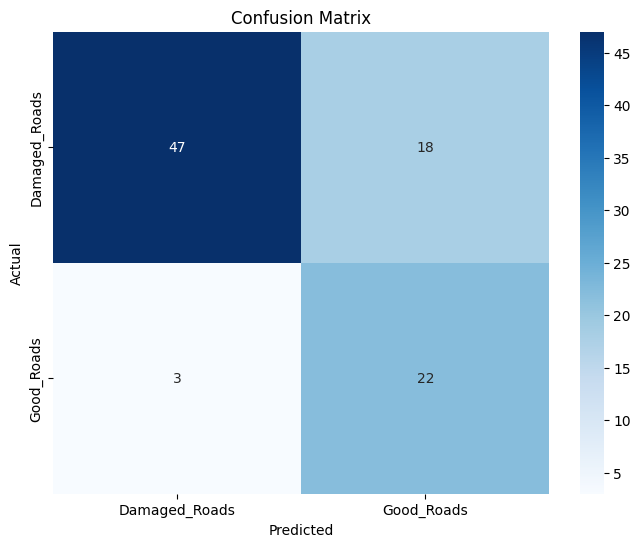

In [ ]:
import os, zipfile, shutil, random
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from PIL import Image

from google.colab import drive
drive.mount('/content/drive')

GOOD_ZIP = "/content/drive/MyDrive/RoadDamageBD/Good_Roads.zip"
BAD_ZIP  = "/content/drive/MyDrive/RoadDamageBD/Damaged_Roads.zip"

print("Using ZIPs:")
print("  Good:", GOOD_ZIP)
print("  Bad :", BAD_ZIP)

for folder in ["/content/roads_raw", "/content/roads_split"]:
    if os.path.exists(folder):
        shutil.rmtree(folder)

os.makedirs("/content/roads_raw", exist_ok=True)
RAW_ROOT = "/content/roads_raw"

def extract_zip_to_class(zip_path, class_name):
    class_dir = os.path.join(RAW_ROOT, class_name)
    os.makedirs(class_dir, exist_ok=True)

    print(f"Extracting: {zip_path}")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(class_dir)

    count = len(os.listdir(class_dir))
    print(f"Extracted {count} images → '{class_name}'")
    return count

good_count = extract_zip_to_class(GOOD_ZIP, "Good_Roads")
bad_count  = extract_zip_to_class(BAD_ZIP, "Damaged_Roads")

SPLIT_ROOT = "/content/roads_split"
TRAIN_DIR = f"{SPLIT_ROOT}/train"
VAL_DIR   = f"{SPLIT_ROOT}/val"

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)

for cls in os.listdir(RAW_ROOT):
    src = os.path.join(RAW_ROOT, cls)
    imgs = os.listdir(src)
    random.shuffle(imgs)

    split = int(0.8 * len(imgs))
    train_imgs = imgs[:split]
    val_imgs   = imgs[split:]

    os.makedirs(f"{TRAIN_DIR}/{cls}", exist_ok=True)
    os.makedirs(f"{VAL_DIR}/{cls}", exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(src, img), f"{TRAIN_DIR}/{cls}/{img}")
    for img in val_imgs:
        shutil.copy(os.path.join(src, img), f"{VAL_DIR}/{cls}/{img}")

print("Train/Val split complete.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR, val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)

class_names = train_ds.classes
num_classes = len(class_names)

print("Classes:", class_names)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )
    def forward(self, x): return self.net(x)

class DepthwiseSeparableBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, 3, stride, 1, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
    def forward(self, x): return torch.relu(self.bn(self.pw(self.dw(x))))

class ResidualDownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.c1 = ConvBlock(in_ch, out_ch, 2)
        self.c2 = ConvBlock(out_ch, out_ch)
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, 2, bias=False),
            nn.BatchNorm2d(out_ch)
        )
    def forward(self, x):
        return torch.relu(self.c2(self.c1(x)) + self.skip(x))

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stem = nn.Sequential(
            ConvBlock(3, 32),
            ConvBlock(32, 32),
            nn.MaxPool2d(2)
        )
        self.s1 = ResidualDownBlock(32, 64)
        self.s2 = nn.Sequential(
            DepthwiseSeparableBlock(64, 128, 2),
            ConvBlock(128, 128)
        )
        self.s3 = nn.Sequential(
            DepthwiseSeparableBlock(128, 256, 2),
            ConvBlock(256, 256)
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.s1(x)
        x = self.s2(x)
        x = self.s3(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)

model = CNN(num_classes).to(device)
print("Model Loaded.")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_acc_hist = []
val_acc_hist   = []
train_loss_hist = []
val_loss_hist   = []

def train_epoch():
    model.train()
    correct, total, loss_sum = 0, 0, 0

    for x, y in tqdm(train_loader, desc="Training"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        correct += (pred.argmax(1) == y).sum().item()
        total   += y.size(0)

    return loss_sum / len(train_loader), correct / total

def validate():
    model.eval()
    correct, total, loss_sum = 0, 0, 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in tqdm(val_loader, desc="Validating"):
            x, y = x.to(device), y.to(device)

            pred = model(x)
            loss = criterion(pred, y)

            loss_sum += loss.item()
            correct += (pred.argmax(1) == y).sum().item()
            total   += y.size(0)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.argmax(1).cpu().numpy())

    return loss_sum / len(val_loader), correct / total, y_true, y_pred

EPOCHS = 5

for epoch in range(1, EPOCHS+1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    t_loss, t_acc = train_epoch()
    v_loss, v_acc, y_true, y_pred = validate()

    train_loss_hist.append(t_loss)
    val_loss_hist.append(v_loss)
    train_acc_hist.append(t_acc)
    val_acc_hist.append(v_acc)

    print(f"Train Acc={t_acc:.3f} | Val Acc={v_acc:.3f}")

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(train_acc_hist, label="Train Acc")
plt.plot(val_acc_hist, label="Val Acc")
plt.title("Accuracy vs Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist, label="Val Loss")
plt.title("Loss vs Epochs")
plt.legend()

plt.show()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()